# Vertical datum: SWOT water-surface elevation and river slope

A river slope is a difference of heights over an along-channel distance. Any **constant** offset between
two vertical datums cancels in that difference, which is why the datum is often waved through as
bookkeeping. What does **not** cancel is the along-channel **gradient** of the datum separation — and for
the ellipsoid-to-geoid separation that gradient turns out to be the same order of magnitude as the river
slopes this study is trying to resolve.

This notebook answers two questions, in order:

1. **Which vertical datum is SWOT `wse` actually on?** The answer decides whether a conversion is a
   refinement or a ~30 m blunder. We settle it against an independent reference rather than by quoting
   the product spec.
2. **How much does the choice of datum change a computed river slope?** This is the part that matters for
   the rating curve, because the uncalibrated HAND synthetic rating curve is Manning (`Q ∝ √S`).

The motivation is physical: a water-surface slope is supposed to mimic the shape of the bed. A slope
computed on the wrong datum mimics the **geoid** instead.

All of it runs from tables committed in `data/` — no SWORD download needed.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
os.environ.pop("PROJ_DATA", None); os.environ.pop("PROJ_LIB", None)   # let pyproj use its own grids
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def _repo_root():
    env = os.environ.get("SLOPE_ROOT")
    if env: return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand/".slope_root").exists() or (cand/"data").is_dir(): return cand
    return here

ROOT = _repo_root(); DATA = ROOT/"data"; OUT = ROOT/"output_final"
(OUT/"tables").mkdir(parents=True, exist_ok=True); (OUT/"figures").mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT/"code"/"tvslope_src"/"engine"))
import datum as D

MM = 1e6            # m/m -> mm/km, the unit river-slope work is usually quoted in
print("repo root :", ROOT)
print("datums    :", {k: v[1] for k, v in D.GEOID_MODELS.items()})
print("SWOT wse is delivered on:", D.SWOT_WSE_DATUM)

repo root : /Users/zixun/2026SI/TVSlope
datums    : {'egm2008': 'EGM2008 geoid (SWOT L2_HR_RiverSP reference)', 'egm96': 'EGM96 geoid (MERIT Hydro / SWORD reference)', 'navd88': 'NAVD88 (US national datum; most USGS gauge alt_va)', 'ngvd29': 'NGVD29 (superseded US datum; still on some gauges)'}
SWOT wse is delivered on: egm2008


## 0. What a geoid undulation actually costs you

`N` is the separation between the WGS84 ellipsoid and the geoid, signed so that `h = H + N`
(ellipsoidal = orthometric + undulation). Across the study region it is roughly **−36 m to −26 m** — so
getting the datum wrong is not a subtle bias, it is tens of metres.

The grids come from the PROJ CDN on first use and are cached locally afterwards.

In [2]:
demo = pd.DataFrame({"site": ["Ohio R. valley", "Illinois R.", "Big Sioux R."],
                     "lon":  [-85.8, -90.2, -96.5], "lat": [38.2, 40.6, 42.9]})
for m in ("egm2008", "egm96", "navd88"):
    demo[f"N_{m} [m]"] = D.geoid_undulation(demo.lon.values, demo.lat.values, m).round(3)
demo["EGM2008-EGM96 [m]"] = (demo["N_egm2008 [m]"] - demo["N_egm96 [m]"]).round(3)
demo

,site,lon,lat,N_egm2008 [m],N_egm96 [m],N_navd88 [m],EGM2008-EGM96 [m]
0,Ohio R. valley,-85.8,38.2,-34.014,-34.339,-34.487,0.325
1,Illinois R.,-90.2,40.6,-33.652,-33.508,-34.261,-0.144
2,Big Sioux R.,-96.5,42.9,-26.012,-26.465,-26.750,0.453


## 1. Which datum is SWOT `wse` on?

SWOT L2_HR_RiverSP delivers `wse` **already referenced to the EGM2008 geoid** — the product applies the
geoid model itself, along with the tidal and media-delay corrections. Rather than take that on faith, we
test it.

Two competing hypotheses, scored against SWORD's own reach `wse` (which comes from MERIT Hydro and is on
**EGM96**, so we first move the reference onto EGM2008 with `convert_geoid` — otherwise we would be
building the very datum mismatch this notebook is about):

* **orthometric** — `wse` is already on the geoid, so compare it directly.
* **ellipsoidal** — `wse` is an ellipsoidal height, so subtract `N` first.

Whichever leaves the smaller residual is the datum SWOT is on.

In [3]:
swot = pd.read_csv(DATA/"swot_hydrocron_study_reaches.csv")
swot = swot[(swot.reach_q <= 1) & swot.wse.between(-100, 5000)]          # keep good-quality observations
med  = swot.groupby("reach_id").wse.median().rename("swot_wse")

sword = pd.read_csv(DATA/"swot_study_reaches_sword.csv")
v = sword.merge(med, on="reach_id")
print(f"{len(swot):,} quality SWOT observations over {v.reach_id.nunique()} reaches")

res = D.verify_swot_datum(v.swot_wse.values, v.wse.values, v.x.values, v.y.values, reference_model="egm96")
pd.Series(res).to_frame("value")

5,609 quality SWOT observations over 83 reaches


,value
n,83
median_residual_if_orthometric_m,0.411897
median_residual_if_ellipsoidal_m,29.233958
verdict,orthometric
margin_m,28.822061


**Verdict: orthometric.** Treating `wse` as already-geoid-referenced leaves a median residual of a few
tens of centimetres against MERIT Hydro; treating it as ellipsoidal leaves ~29 m. The margin is not close.

So *"convert SWOT from WGS84 to the geoid"* would **subtract a ~30 m undulation that has already been
removed**. The conversion is not a refinement here — it is the error.

In [4]:
v["N_egm2008"]        = D.geoid_undulation(v.x.values, v.y.values, "egm2008")
v["N_egm96"]          = D.geoid_undulation(v.x.values, v.y.values, "egm96")
v["sword_on_egm2008"] = D.convert_geoid(v.x.values, v.y.values, v.wse.values, "egm96", "egm2008")
v["resid_orthometric_m"]    = v.swot_wse - v.sword_on_egm2008
v["resid_if_ellipsoidal_m"] = (v.swot_wse - v.N_egm2008) - v.sword_on_egm2008
v.to_csv(OUT/"tables"/"swot_datum_verification.csv", index=False)

print(f"geoid undulation N over the study reaches: {v.N_egm2008.min():.2f} to {v.N_egm2008.max():.2f} m")
v[["resid_orthometric_m", "resid_if_ellipsoidal_m"]].describe().T.round(2)

geoid undulation N over the study reaches: -36.60 to -25.95 m


,count,mean,std,min,25%,50%,75%,max
resid_orthometric_m,83.0,0.51,1.98,-4.91,-0.44,0.41,1.31,5.88
resid_if_ellipsoidal_m,83.0,30.69,4.06,24.42,28.04,29.23,34.03,41.40


## 2. The part that actually bites: the geoid's along-channel gradient

Now the question that matters for slope. Write the water-surface slope computed from ellipsoidal heights:

$$\frac{dh}{dx} \;=\; \underbrace{\frac{dH}{dx}}_{\text{the river slope you want}} \;+\; \underbrace{\frac{dN}{dx}}_{\text{the geoid gradient you did not ask for}}$$

The constant part of `N` cancels; the **gradient** does not. `dN/dx` is a systematic, spatially correlated
error term added straight onto the slope.

We compute it per reach from the SWORD node chain, using `dist_out` (distance to outlet) as the
along-channel coordinate, and compare it against the river's own water-surface slope.

In [5]:
nodes = pd.read_csv(DATA/"swot_study_reach_nodes.csv")
nodes["N08"] = D.geoid_undulation(nodes.x.values, nodes.y.values, "egm2008")
nodes["N96"] = D.geoid_undulation(nodes.x.values, nodes.y.values, "egm96")
nodes = nodes[np.isfinite(nodes.N08) & np.isfinite(nodes.N96)]

rows = []
for rid, g in nodes.groupby("reach_id"):
    g = g.sort_values("dist_out")
    if len(g) < 3 or np.ptp(g.dist_out.values) < 500:      # need a real chain to fit a gradient
        continue
    x = g.dist_out.values
    rows.append(dict(
        reach_id          = rid,
        n_nodes           = len(g),
        reach_len_km      = np.ptp(x)/1000,
        dNdx_egm2008_mmkm = D.geoid_slope_bias(g.x.values, g.y.values, x, "egm2008")*MM,
        dNdx_egm96_mmkm   = D.geoid_slope_bias(g.x.values, g.y.values, x, "egm96")*MM,
        river_slope_mmkm  = D.along_channel_slope(x, g.wse.values)*MM,
    ))
s = pd.DataFrame(rows)
s["model_diff_slope_mmkm"] = s.dNdx_egm2008_mmkm - s.dNdx_egm96_mmkm
s["abs_river_slope_mmkm"]  = s.river_slope_mmkm.abs()
s["abs_dNdx_mmkm"]         = s.dNdx_egm2008_mmkm.abs()

# SWORD assigns a ~0 slope to lake-flagged / flat reaches; a ratio there is meaningless, so gate on a
# slope we could actually resolve (1 cm/km).
RESOLVABLE = 10.0
s["resolvable"]          = s.abs_river_slope_mmkm >= RESOLVABLE
s["geoid_pct_of_slope"]  = np.where(s.resolvable, 100*s.abs_dNdx_mmkm/s.abs_river_slope_mmkm, np.nan)
s.to_csv(OUT/"tables"/"geoid_slope_sensitivity.csv", index=False)

print(f"{len(s)} reaches, median length {s.reach_len_km.median():.1f} km; "
      f"{s.resolvable.sum()} with a resolvable slope (>= {RESOLVABLE:g} mm/km)")
s[["abs_dNdx_mmkm", "model_diff_slope_mmkm", "abs_river_slope_mmkm", "geoid_pct_of_slope"]].describe(
    percentiles=[.5, .9]).T.round(2)

92 reaches, median length 10.0 km; 70 with a resolvable slope (>= 10 mm/km)


,count,mean,std,min,50%,90%,max
abs_dNdx_mmkm,92.0,7.15,7.63,0.04,4.08,16.19,32.93
model_diff_slope_mmkm,92.0,0.44,3.45,-11.08,0.17,4.00,12.97
abs_river_slope_mmkm,92.0,103.31,102.55,0.00,75.36,221.00,408.83
geoid_pct_of_slope,70.0,11.37,18.25,0.11,4.28,26.42,96.93


In [6]:
r = s[s.resolvable]
print("along-channel geoid gradient |dN/dx|, EGM2008 [mm/km]")
print(f"    median {s.abs_dNdx_mmkm.median():6.2f}   p90 {s.abs_dNdx_mmkm.quantile(.9):6.2f}"
      f"   max {s.abs_dNdx_mmkm.max():6.2f}")
print("river water-surface slope |S| [mm/km]")
print(f"    median {r.abs_river_slope_mmkm.median():6.2f}   p90 {r.abs_river_slope_mmkm.quantile(.9):6.2f}"
      f"   max {r.abs_river_slope_mmkm.max():6.2f}")
print()
print(f"reaches where |dN/dx| exceeds SWOT's own 17 mm/km reach-slope requirement : "
      f"{(s.abs_dNdx_mmkm > 17).sum():3d} / {len(s)}")
print(f"reaches where |dN/dx| exceeds 10% of the river slope                      : "
      f"{(r.geoid_pct_of_slope > 10).sum():3d} / {len(r)}")
print(f"reaches where |dN/dx| exceeds 50% of the river slope                      : "
      f"{(r.geoid_pct_of_slope > 50).sum():3d} / {len(r)}")

along-channel geoid gradient |dN/dx|, EGM2008 [mm/km]
    median   4.08   p90  16.19   max  32.93
river water-surface slope |S| [mm/km]
    median 135.16   p90 254.79   max 408.83

reaches where |dN/dx| exceeds SWOT's own 17 mm/km reach-slope requirement :   8 / 92
reaches where |dN/dx| exceeds 10% of the river slope                      :  21 / 70
reaches where |dN/dx| exceeds 50% of the river slope                      :   3 / 70


This is the result worth carrying out of the notebook. The geoid gradient is a **median 4 mm/km** and
reaches **33 mm/km** — against a median river slope of ~135 mm/km. On a fifth of the reaches it is worth
more than 10% of the slope, and on a handful it is worth more than half. On 8 reaches it alone exceeds the
17 mm/km accuracy SWOT is specified to deliver for a reach slope.

Put plainly: **slope computed from ellipsoidal heights partly maps the geoid, not the river.** Because the
uncalibrated synthetic rating curve is Manning (`Q ∝ √S`), a 10% slope error moves discharge ~5% at fixed
stage, and it does so with a spatial pattern that looks like real topography — which is exactly the kind of
error that survives visual inspection.

## 3. Mixing geoid models is its own error

The three datasets in this study do **not** share a geoid:

| Dataset | Geoid |
|---|---|
| SWOT L2_HR_RiverSP `wse` | **EGM2008** |
| SWORD / MERIT Hydro `wse` | **EGM96** |
| IRIS | **EIGEN-6C4** |

Differencing heights across two models injects the *difference between the models* into the slope. Between
EGM2008 and EGM96 that is a median 1.2 mm/km and up to 13 mm/km on these reaches — small next to a steep
river, not small next to a flat one, and entirely avoidable: put everything on one model with
`convert_geoid()` first.

In [7]:
print("EGM2008 - EGM96 slope difference [mm/km]")
print(f"    median {s.model_diff_slope_mmkm.abs().median():.2f}   "
      f"p90 {s.model_diff_slope_mmkm.abs().quantile(.9):.2f}   "
      f"max {s.model_diff_slope_mmkm.abs().max():.2f}")

# worked example: one reach, its slope on each vertical datum
rid = s.loc[s.abs_dNdx_mmkm.idxmax(), "reach_id"]
g = nodes[nodes.reach_id == rid].sort_values("dist_out")
x, H08 = g.dist_out.values, g.wse.values           # SWORD wse is EGM96
H96_to_08 = D.convert_geoid(g.x.values, g.y.values, H08, "egm96", "egm2008")
h_ellip   = D.orthometric_to_ellipsoidal(g.x.values, g.y.values, H08, "egm96")

print(f"\nworked example -- reach {rid} ({g.river_name.iloc[0]}), {np.ptp(x)/1000:.1f} km")
for lab, hh in [("orthometric, EGM96 (as delivered)", H08),
                ("orthometric, EGM2008", H96_to_08),
                ("ellipsoidal, WGS84", h_ellip)]:
    print(f"    slope on {lab:36s} {D.along_channel_slope(x, hh)*MM:8.2f} mm/km")
print(f"    -> the ellipsoidal figure is wrong by "
      f"{abs(D.along_channel_slope(x,h_ellip)-D.along_channel_slope(x,H08))*MM:.2f} mm/km")

EGM2008 - EGM96 slope difference [mm/km]
    median 1.18   p90 6.15   max 12.97

worked example -- reach 74241300241 (Arkansas River), 10.8 km
    slope on orthometric, EGM96 (as delivered)      158.42 mm/km
    slope on orthometric, EGM2008                   167.43 mm/km
    slope on ellipsoidal, WGS84                     134.50 mm/km
    -> the ellipsoidal figure is wrong by 23.92 mm/km


## 4. The same problem on the ground: USGS gauge datums

The geoid is not the only vertical datum in this study. The time-varying gauge slope is built as

    S = (WSE_upstream − WSE_downstream) / span,     WSE = alt_va + stage

where `alt_va` is the gauge's datum elevation from NWIS. NWIS reports `alt_va` against whatever
`alt_datum_cd` says — usually **NAVD88**, but **NGVD29** is still common, and `LOCAL`/`ASSUMED` mean an
arbitrary local mark. The original code read `alt_va` and ignored `alt_datum_cd`, so when the two gauges
of a pair sat on different datums the NGVD29↔NAVD88 offset went straight into the slope.

`datum.gauge_elevation_to()` converts each gauge onto one datum (`GAUGE_REF_DATUM`, NAVD88) and refuses a
gauge whose datum is unusable, rather than returning a number that quietly poisons the pair.

In [8]:
from pyproj import Geod
_geod = Geod(ellps="WGS84")

gd = pd.read_csv(DATA/"study_gauge_datums.csv", dtype={"site_no": str})
print("vertical datum reported for the study's gauges:")
print(gd.alt_datum_cd.value_counts().to_string())
print(f"\nNGVD29 -> NAVD88 shift [m]: min {gd[gd.alt_datum_cd=='NGVD29'].shift_m.min():+.4f}"
      f"   median {gd[gd.alt_datum_cd=='NGVD29'].shift_m.median():+.4f}"
      f"   max {gd[gd.alt_datum_cd=='NGVD29'].shift_m.max():+.4f}")

# Which twin-gauge pairs are split across two datums, and what does that do to the slope?
M = gd.set_index("site_no")
ga = pd.read_csv(DATA/"study_area_gauges.csv", dtype={"upstream_gauge_id": str, "downstream_gauge_id": str})
rows = []
for _, gr in ga.dropna(subset=["upstream_gauge_id", "downstream_gauge_id"]).iterrows():
    u, d_ = gr.upstream_gauge_id, gr.downstream_gauge_id
    if u not in M.index or d_ not in M.index: continue
    a, b = M.loc[u], M.loc[d_]
    if not (np.isfinite(a.alt_navd88_m) and np.isfinite(b.alt_navd88_m)): continue
    _, _, span = _geod.inv(a.dec_long_va, a.dec_lat_va, b.dec_long_va, b.dec_lat_va)
    if span < 100: continue
    rows.append(dict(reach_id=gr.reach_id, river=gr.river_name, cd_up=a.alt_datum_cd, cd_dn=b.alt_datum_cd,
                     mismatch=a.alt_datum_cd != b.alt_datum_cd, span_km=span/1000,
                     slope_old_mmkm=(a.alt_va_m - b.alt_va_m)/span*MM,
                     slope_new_mmkm=(a.alt_navd88_m - b.alt_navd88_m)/span*MM))
pairs = pd.DataFrame(rows).drop_duplicates(subset=["reach_id", "cd_up", "cd_dn"])
pairs["artefact_mmkm"] = pairs.slope_old_mmkm - pairs.slope_new_mmkm
pairs["artefact_pct"]  = 100*pairs.artefact_mmkm.abs()/pairs.slope_new_mmkm.abs()
pairs.to_csv(OUT/"tables"/"gauge_datum_mismatch.csv", index=False)

mis = pairs[pairs.mismatch]
print(f"\ntwin-gauge pairs resolved: {len(pairs)}   datum-MISMATCHED: {len(mis)}")
mis[["reach_id","river","cd_up","cd_dn","span_km","slope_old_mmkm","slope_new_mmkm",
     "artefact_mmkm","artefact_pct"]].round(2)

vertical datum reported for the study's gauges:
alt_datum_cd
NAVD88    79
NGVD29     6
(none)     3

NGVD29 -> NAVD88 shift [m]: min -0.2488   median -0.0893   max +0.1216

twin-gauge pairs resolved: 78   datum-MISMATCHED: 7


,reach_id,river,cd_up,cd_dn,span_km,slope_old_mmkm,slope_new_mmkm,artefact_mmkm,artefact_pct
10,74267300251,Ohio River,NAVD88,NGVD29,3.10,3297.13,3344.44,-47.31,1.41
14,73160100141,Susquehanna River,NAVD88,NGVD29,37.55,720.57,727.19,-6.62,0.91
36,74261000021,Ohio River,NAVD88,NGVD29,21.93,106.45,100.91,5.54,5.49
50,75120400111,Neches River,NGVD29,NAVD88,48.57,-41.67,-41.68,0.01,0.03
51,75120400121,Neches River,NGVD29,NAVD88,48.57,-41.67,-41.68,0.01,0.03
71,74267300241,Ohio River,NGVD29,NAVD88,18.47,14.35,6.42,7.93,123.47
76,75120500161,Sabine River,NAVD88,NGVD29,24.89,-409.18,-407.32,-1.86,0.46


In [9]:
print(f"slope artefact removed |ΔS| [mm/km]: median {mis.artefact_mmkm.abs().median():.2f}"
      f"   max {mis.artefact_mmkm.abs().max():.2f}")
print(f"as a share of the corrected slope: median {mis.artefact_pct.median():.1f} %"
      f"   max {mis.artefact_pct.max():.1f} %")
print()
worst = mis.loc[mis.artefact_pct.idxmax()]
print(f"worst case -- reach {worst.reach_id} ({worst.river}), {worst.span_km:.1f} km:")
print(f"    slope on the raw, mismatched datums : {worst.slope_old_mmkm:8.2f} mm/km")
print(f"    slope with both gauges on NAVD88    : {worst.slope_new_mmkm:8.2f} mm/km")
print(f"    the datum artefact was {worst.artefact_pct:.0f} % of the corrected slope.")
print()
print("Note the pattern: the artefact is a fixed offset in metres, so it is negligible on a steep")
print("reach and dominant on a flat one -- worst exactly where the slope signal is weakest, which is")
print("the backwater regime this study finds to be first-order.")

slope artefact removed |ΔS| [mm/km]: median 5.54   max 47.31
as a share of the corrected slope: median 0.9 %   max 123.5 %

worst case -- reach 74267300241 (Ohio River), 18.5 km:
    slope on the raw, mismatched datums :    14.35 mm/km
    slope with both gauges on NAVD88    :     6.42 mm/km
    the datum artefact was 123 % of the corrected slope.

Note the pattern: the artefact is a fixed offset in metres, so it is negligible on a steep
reach and dominant on a flat one -- worst exactly where the slope signal is weakest, which is
the backwater regime this study finds to be first-order.


## 5. Figure

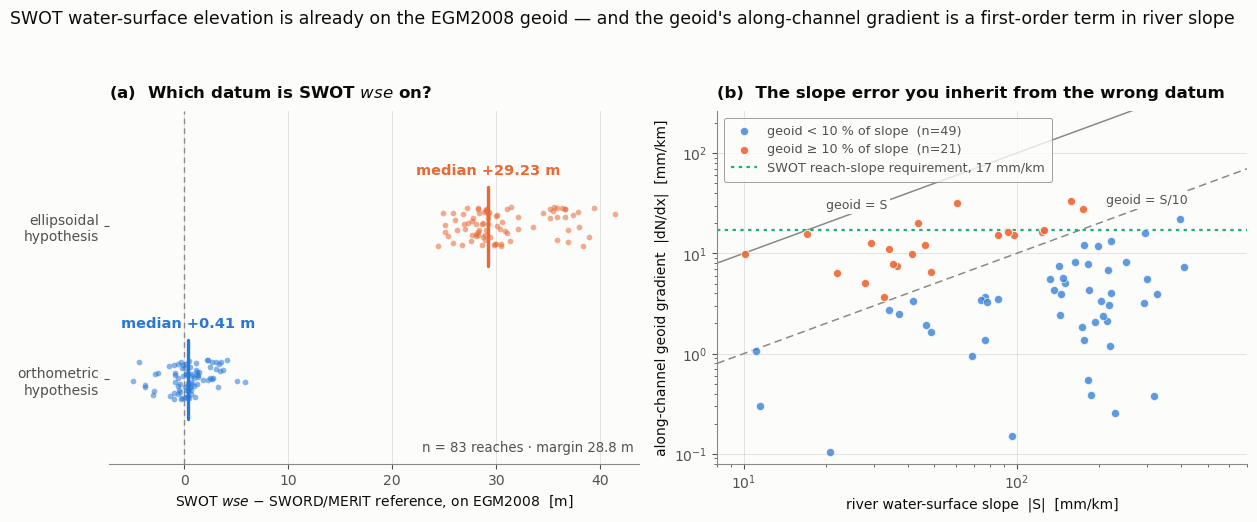

In [10]:
SURF, INK, INK2, MUTE = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"font.size":10,"axes.edgecolor":MUTE,"axes.labelcolor":INK,"text.color":INK,
    "xtick.color":INK2,"ytick.color":INK2,"axes.linewidth":.8,"figure.facecolor":SURF,"axes.facecolor":SURF})
from matplotlib.lines import Line2D

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12.6,5.2))
d_o, d_e = v.resid_orthometric_m.dropna().values, v.resid_if_ellipsoidal_m.dropna().values
rng = np.random.default_rng(0)
for i,(d,c,_) in enumerate([(d_o,BLUE,""),(d_e,ORANGE,"")]):
    ax1.scatter(d, i+rng.uniform(-.13,.13,len(d)), s=17, color=c, alpha=.55, linewidths=0, zorder=3)
    m = np.median(d)
    ax1.plot([m,m],[i-.26,i+.26], color=c, lw=2.4, zorder=4, solid_capstyle="round")
    ax1.annotate(f"median {m:+.2f} m",(m,i+.34),color=c,fontsize=10.5,fontweight="bold",ha="center",zorder=5)
ax1.axvline(0,color=MUTE,lw=1,ls=(0,(4,3)),zorder=1)
ax1.set_yticks([0,1]); ax1.set_yticklabels(["orthometric\nhypothesis","ellipsoidal\nhypothesis"])
ax1.set_ylim(-.55,1.75); ax1.set_xlabel("SWOT $wse$ − SWORD/MERIT reference, on EGM2008  [m]")
ax1.set_title("(a)  Which datum is SWOT $wse$ on?",loc="left",fontsize=12,fontweight="bold",pad=10)
ax1.text(.99,.035,f"n = {len(d_o)} reaches · margin {abs(abs(np.median(d_e))-abs(np.median(d_o))):.1f} m",
         transform=ax1.transAxes,ha="right",color=INK2,fontsize=9.5)
ax1.grid(axis="x",color=MUTE,alpha=.22,lw=.7); ax1.set_axisbelow(True)
for sp in ("top","right","left"): ax1.spines[sp].set_visible(False)

hi = r.geoid_pct_of_slope >= 10
ax2.scatter(r.abs_river_slope_mmkm[~hi], r.abs_dNdx_mmkm[~hi], s=34, color=BLUE, alpha=.75,
            linewidths=.6, edgecolors=SURF, zorder=3, label=f"geoid < 10 % of slope  (n={(~hi).sum()})")
ax2.scatter(r.abs_river_slope_mmkm[hi], r.abs_dNdx_mmkm[hi], s=34, color=ORANGE, alpha=.9,
            linewidths=.6, edgecolors=SURF, zorder=4, label=f"geoid ≥ 10 % of slope  (n={hi.sum()})")
xs = np.array([8,700])
ax2.plot(xs,xs,color=MUTE,lw=1.1,zorder=2); ax2.plot(xs,.1*xs,color=MUTE,lw=1.1,ls=(0,(5,3)),zorder=2)
ax2.axhline(17,color=AQUA,lw=1.6,ls=(0,(1.5,2)),zorder=2)
bb = dict(facecolor=SURF,edgecolor="none",pad=1.6)
ax2.text(26,30,"geoid = S",color=INK2,fontsize=9,ha="center",va="center",bbox=bb,zorder=5)
ax2.text(300,34,"geoid = S/10",color=INK2,fontsize=9,ha="center",va="center",bbox=bb,zorder=5)
ax2.set_xscale("log"); ax2.set_yscale("log"); ax2.set_xlim(8,700); ax2.set_ylim(.08,260)
ax2.set_xlabel("river water-surface slope  |S|  [mm/km]")
ax2.set_ylabel("along-channel geoid gradient  |dN/dx|  [mm/km]")
ax2.set_title("(b)  The slope error you inherit from the wrong datum",loc="left",fontsize=12,
              fontweight="bold",pad=10)
h,l = ax2.get_legend_handles_labels()
h.append(Line2D([],[],color=AQUA,lw=1.6,ls=(0,(1.5,2)))); l.append("SWOT reach-slope requirement, 17 mm/km")
leg = ax2.legend(h,l,loc="upper left",frameon=True,fontsize=9.2,borderpad=.6)
leg.get_frame().set_edgecolor(MUTE); leg.get_frame().set_facecolor(SURF); leg.get_frame().set_linewidth(.7)
for t in leg.get_texts(): t.set_color(INK2)
ax2.grid(color=MUTE,alpha=.22,lw=.7); ax2.set_axisbelow(True)
for sp in ("top","right"): ax2.spines[sp].set_visible(False)

fig.suptitle("SWOT water-surface elevation is already on the EGM2008 geoid — and the geoid's "
             "along-channel gradient is a first-order term in river slope",
             fontsize=12.5,color=INK,y=.995,x=.006,ha="left")
fig.tight_layout(rect=[0,0,1,.945])
for ext in ("png","svg"):
    fig.savefig(OUT/"figures"/f"geoid_datum_slope.{ext}", dpi=200, facecolor=SURF, bbox_inches="tight")
plt.show()

## What to do in the pipeline

1. **Do not "convert SWOT to the geoid."** `wse` arrives on EGM2008. Subtracting `N` is a ~30 m error.
   `datum.SWOT_WSE_DATUM` records this, and `verify_swot_datum()` re-checks it on any new pull.
2. **Put every height source on one datum before differencing**, with `datum.convert_vertical()`. SWOT is
   EGM2008, SWORD/MERIT is EGM96, IRIS is EIGEN-6C4 — and USGS gauge `alt_va` is NAVD88 *or* NGVD29
   depending on the station.
3. **Gauge pairs are now harmonised automatically.** `engine/per_reach3.py` converts every `alt_va` onto
   `datum.GAUGE_REF_DATUM` (NAVD88) via `gauge_elevation_to()` before building `wse_series`, and returns
   NaN for a gauge on a `LOCAL`/`ASSUMED` datum instead of a number that silently poisons the pair. This
   changes the published `S(Q)` on the 7 mismatched pairs above.
4. **If a height source ever is ellipsoidal** (raw altimetry, some DEM products, GNSS), convert with
   `ellipsoidal_to_orthometric()` *before* fitting a slope — never after, and never by removing a single
   mean offset for the whole reach, because it is the gradient that hurts.
5. **Never ask for an undulation on a levelling datum.** NGVD29 has no grid to the ellipsoid; PROJ answers
   with a silent pass-through that is wrong by ~34 m. `geoid_undulation()` refuses it by design.
6. **Report which datum a slope was computed on.** At these magnitudes it is part of the number.

One caveat on scope: `code/tvslope_src/sebastian/` is a frozen parallel reading of the same question and
still carries the original, unharmonised `per_reach3`. It is left as it was so its committed notebook
outputs stay reproducible; the fix above lives in `engine/`.